Задание 5

Чтение последовательностей
Длина генома неандертальца: 16565 п.н.
Длина генома человека: 16569 п.н.
Разница в длине: 4 п.н.
Строим DotPlot
Построение индекса для последовательности 2 (k=15)...
Поиск совпадений...
Прогресс: 1000/16551 (6.0%)
Прогресс: 2000/16551 (12.1%)
Прогресс: 3000/16551 (18.1%)
Прогресс: 4000/16551 (24.2%)
Прогресс: 5000/16551 (30.2%)
Прогресс: 6000/16551 (36.3%)
Прогресс: 7000/16551 (42.3%)
Прогресс: 8000/16551 (48.3%)
Прогресс: 9000/16551 (54.4%)
Прогресс: 10000/16551 (60.4%)
Прогресс: 11000/16551 (66.5%)
Прогресс: 12000/16551 (72.5%)
Прогресс: 13000/16551 (78.5%)
Прогресс: 14000/16551 (84.6%)
Прогресс: 15000/16551 (90.6%)
Прогресс: 16000/16551 (96.7%)
Найдено 13753 совпадений
Результаты:
Совпадений на главной диагонали: 100.0%
Совпадений с инверсией: 0.7%


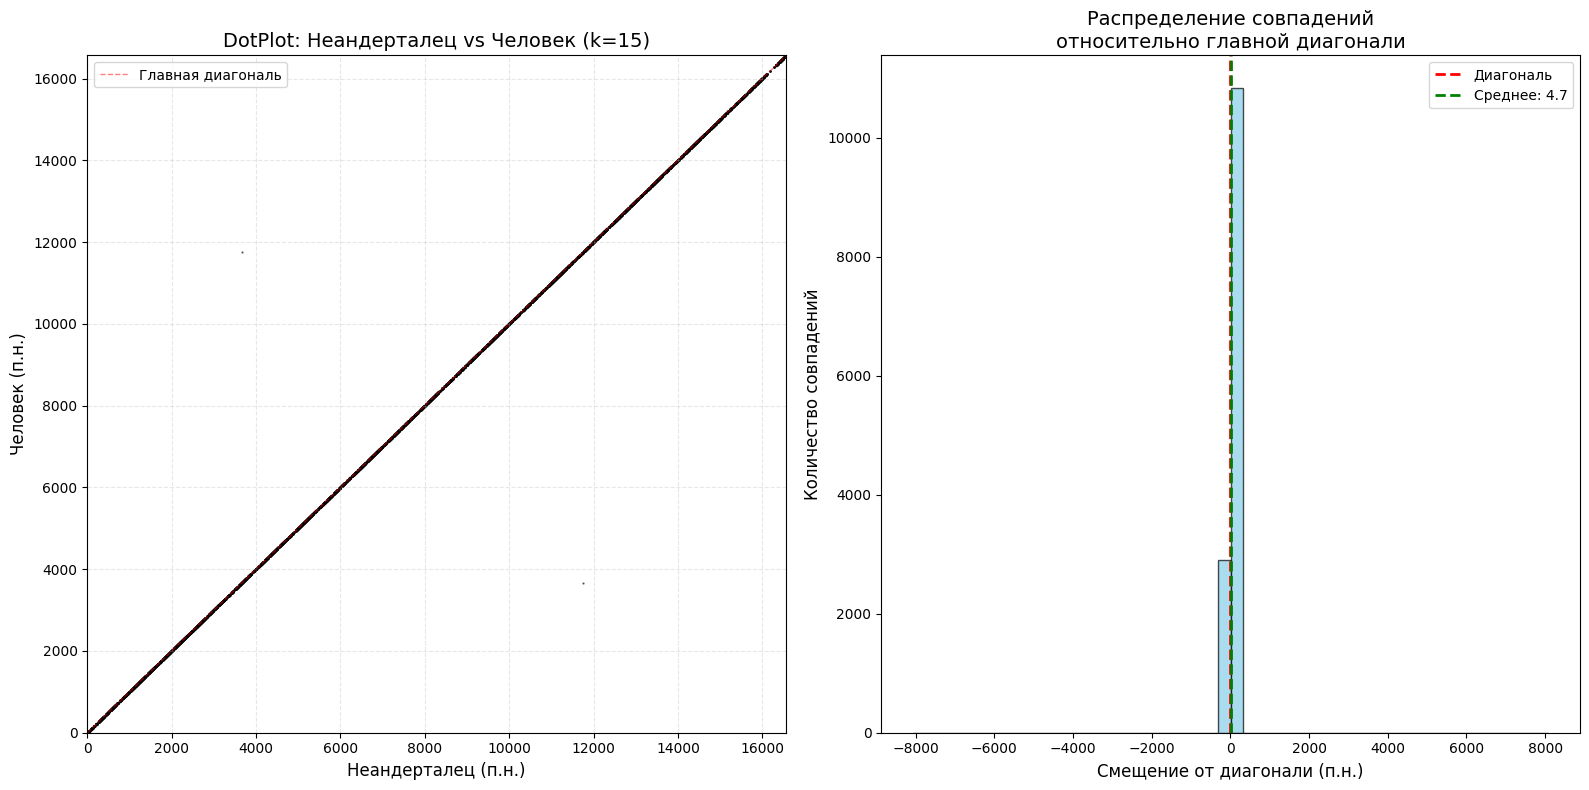


Построение дополнительных графиков с разными k...
Построение индекса для последовательности 2 (k=10)...
Поиск совпадений...
Прогресс: 1000/16556 (6.0%)
Прогресс: 2000/16556 (12.1%)
Прогресс: 3000/16556 (18.1%)
Прогресс: 4000/16556 (24.2%)
Прогресс: 5000/16556 (30.2%)
Прогресс: 6000/16556 (36.2%)
Прогресс: 7000/16556 (42.3%)
Прогресс: 8000/16556 (48.3%)
Прогресс: 9000/16556 (54.4%)
Прогресс: 10000/16556 (60.4%)
Прогресс: 11000/16556 (66.4%)
Прогресс: 12000/16556 (72.5%)
Прогресс: 13000/16556 (78.5%)
Прогресс: 14000/16556 (84.6%)
Прогресс: 15000/16556 (90.6%)
Прогресс: 16000/16556 (96.6%)
Найдено 15514 совпадений
Построение индекса для последовательности 2 (k=15)...
Поиск совпадений...
Прогресс: 1000/16551 (6.0%)
Прогресс: 2000/16551 (12.1%)
Прогресс: 3000/16551 (18.1%)
Прогресс: 4000/16551 (24.2%)
Прогресс: 5000/16551 (30.2%)
Прогресс: 6000/16551 (36.3%)
Прогресс: 7000/16551 (42.3%)
Прогресс: 8000/16551 (48.3%)
Прогресс: 9000/16551 (54.4%)
Прогресс: 10000/16551 (60.4%)
Прогресс: 11000/

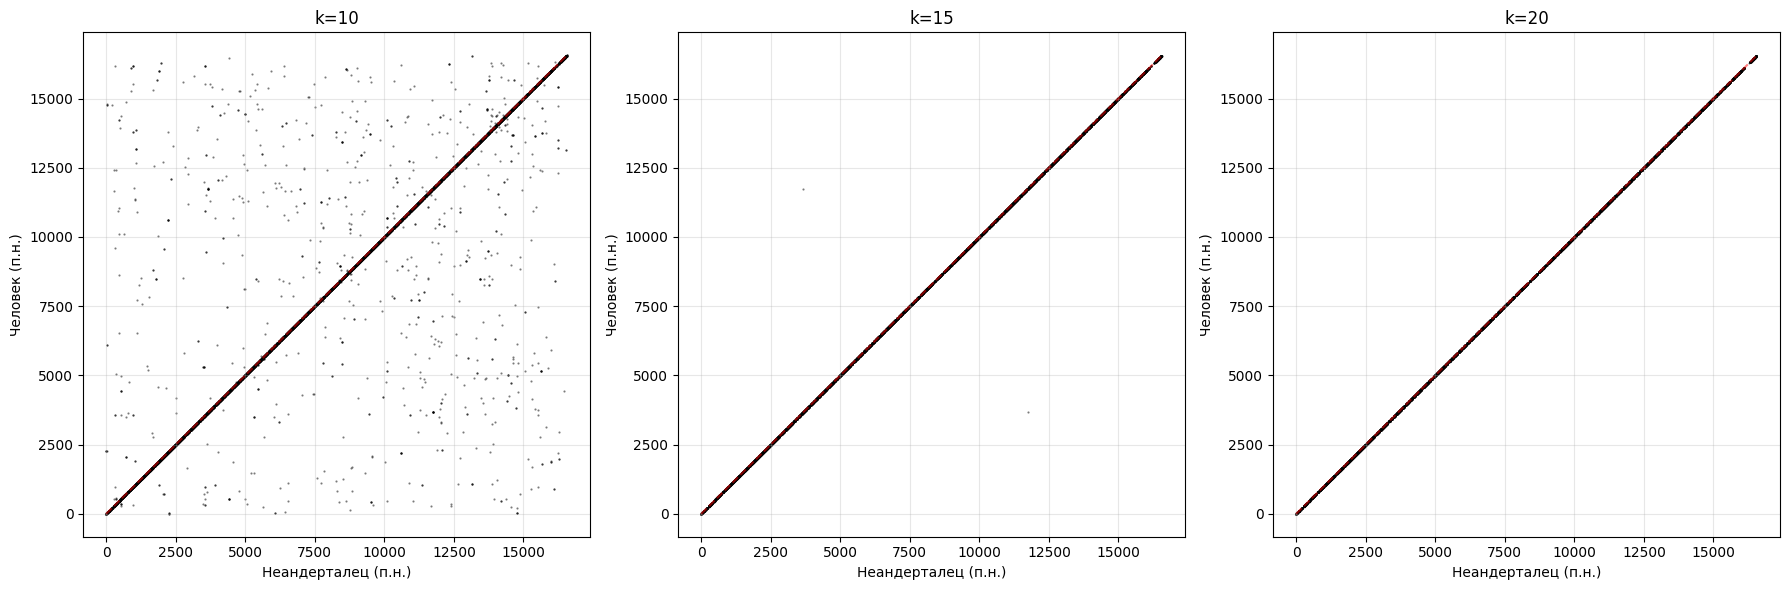

In [3]:
import matplotlib.pyplot as plt
from Bio import SeqIO
from collections import defaultdict
import numpy as np

def read_fasta(path):
    """Чтение последовательности из FASTA файла"""
    record = SeqIO.read(path, "fasta")
    return str(record.seq).upper()

def build_kmer_index(sequence, k):
    """Создание индекса k-mer'ов для быстрого поиска"""
    index = defaultdict(list)
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        index[kmer].append(i)
    return index

def dotplot_kmer(seq1, seq2, k=15, max_points=100000):
    """
    Построение DotPlot с использованием k-mer индексации

    Параметры:
    seq1, seq2 - последовательности
    k - размер k-mer
    max_points - максимальное количество точек (для производительности)
    """
    print(f"Построение индекса для последовательности 2 (k={k})...")
    index = build_kmer_index(seq2, k)

    print("Поиск совпадений...")
    x_coords = []
    y_coords = []

    total_kmers = len(seq1) - k + 1
    for i in range(total_kmers):
        if i % 1000 == 0 and i > 0:
            print(f"Прогресс: {i}/{total_kmers} ({i/total_kmers*100:.1f}%)")

        kmer = seq1[i:i+k]
        if kmer in index:
            for j in index[kmer]:
                x_coords.append(i)
                y_coords.append(j)

                if len(x_coords) >= max_points:
                    print(f"Достигнут лимит в {max_points} точек")
                    return x_coords, y_coords

    print(f"Найдено {len(x_coords)} совпадений")
    return x_coords, y_coords

def analyze_dotplot(x_coords, y_coords, len1, len2):
    """Анализ паттернов на DotPlot"""
    if len(x_coords) == 0:
        return "Нет совпадений для анализа"

    x = np.array(x_coords)
    y = np.array(y_coords)

    diff = y - x

    diagonal_mask = np.abs(diff) < 100
    diagonal_percentage = np.sum(diagonal_mask) / len(x) * 100

    inverse_mask = np.abs(y + x - len1) < 100
    inverse_percentage = np.sum(inverse_mask) / len(x) * 100

    return diagonal_percentage, inverse_percentage

def plot_with_analysis(x, y, len1, len2, k):
    """Построение графика с анализом"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    ax1.scatter(x, y, s=0.5, c='black', alpha=0.5)
    ax1.set_xlabel("Неандерталец (п.н.)", fontsize=12)
    ax1.set_ylabel("Человек (п.н.)", fontsize=12)
    ax1.set_title(f"DotPlot: Неандерталец vs Человек (k={k})", fontsize=14)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xlim(0, len1)
    ax1.set_ylim(0, len2)

    ax1.plot([0, min(len1, len2)], [0, min(len1, len2)],
             'r--', linewidth=1, alpha=0.5, label='Главная диагональ')
    ax1.legend()

    # Гистограмма распределения совпадений относительно диагонали
    if len(x) > 0:
        diff = np.array(y) - np.array(x)
        ax2.hist(diff, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        ax2.set_xlabel("Смещение от диагонали (п.н.)", fontsize=12)
        ax2.set_ylabel("Количество совпадений", fontsize=12)
        ax2.set_title("Распределение совпадений\nотносительно главной диагонали", fontsize=14)
        ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Диагональ')
        ax2.axvline(x=np.mean(diff), color='green', linestyle='--',
                   linewidth=2, label=f'Среднее: {np.mean(diff):.1f}')
        ax2.legend()

    plt.tight_layout()
    plt.savefig('mtDNA_dotplot_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig

if __name__ == "__main__":
    neanderthal_file = "sequence.fasta"
    human_file = "sequence (1).fasta"

    print("Чтение последовательностей")

    seq1 = read_fasta(neanderthal_file)  # Неандерталец
    seq2 = read_fasta(human_file)        # Человек

    print(f"Длина генома неандертальца: {len(seq1):} п.н.")
    print(f"Длина генома человека: {len(seq2):} п.н.")
    print(f"Разница в длине: {abs(len(seq1) - len(seq2))} п.н.")

    k_values = [10, 15, 20]  # Разные размеры k-mer

    print("Строим DotPlot")

    # k=15 (оптимальное значение)
    k = 15
    x, y = dotplot_kmer(seq1, seq2, k=k, max_points=200000)

    diag_perc, inv_perc = analyze_dotplot(x, y, len(seq1), len(seq2))

    print("Результаты:")
    print(f"Совпадений на главной диагонали: {diag_perc:.1f}%")
    print(f"Совпадений с инверсией: {inv_perc:.1f}%")

    plot_with_analysis(x, y, len(seq1), len(seq2), k)

    # Графики с разными k для сравнения
    if len(seq1) < 20000:
        print("\nПостроение дополнительных графиков с разными k...")

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        for idx, test_k in enumerate([10, 15, 20]):
            x_test, y_test = dotplot_kmer(seq1, seq2, k=test_k, max_points=50000)

            axes[idx].scatter(x_test, y_test, s=0.3, c='black', alpha=0.5)
            axes[idx].set_xlabel("Неандерталец (п.н.)")
            axes[idx].set_ylabel("Человек (п.н.)")
            axes[idx].set_title(f"k={test_k}")
            axes[idx].grid(True, alpha=0.3)
            axes[idx].plot([0, min(len(seq1), len(seq2))],
                          [0, min(len(seq1), len(seq2))],
                          'r--', alpha=0.5)

        plt.tight_layout()
        plt.savefig('mtDNA_dotplot_comparison.png', dpi=300)
        plt.show()

Митохондриальные геномы неандертальца и современного человека демонстрируют практически полную синтению. На DotPlot наблюдается сплошная главная диагональ без выраженных разрывов или обратных диагоналей. Крупные структурные перестройки (инверсии, большие делеции или дупликации) отсутствуют; различия носят точечный характер.